The following notebook analyses bureau and bureau balance. The ultimate goal is to create a model that agglomerates the time series information of each individual into a more interpretable metric.

In [ ]:
from helpers import preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from helpers.utils import plotting_helper
from helpers.utils.cleaner_helper import plot_categorical_dist
plotting_helper.set_plot_style()


from sklearn.metrics import roc_auc_score
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import confusion_matrix
from helpers.custom_classifiers import MarkovPredictor

# Bureau balance

In [2]:
balance = preprocessing.load_pkl_to_preprocessor('bureau_balance')
balance.convert_all('category')
balance_cols = balance.column_structure
print("columns of interest:", balance_cols)
balance.data.sort_values(['SK_ID_BUREAU', 'MONTHS_BALANCE'], ascending=(True, True), inplace=True)


Loading tables: ['bureau_balance.csv']
loaded bureau_balance with shape (27299925, 3)
dict_keys(['credit_status', 'bureau_overdue', 'time_variables', 'bureau', 'bureau_balance', 'pos_cash_balance', 'balance_limits', 'drawings_payments', 'contract_installments', 'credit_card_balance', 'previous_application', 'installments_payments'])
No missing columns.
Unexpected columns: ['SK_ID_BUREAU']
columns of interest: ['SK_ID_BUREAU', 'MONTHS_BALANCE', 'STATUS']


bureau balance includes just three columns (from nb2):
* `SKI_ID_BUREAU` id of relevant application
* `MONTHS_BALANCE` time in months relative to application date.
    * `C`: Closed - Account was closed during (or by the end of) the month—no outstanding balance.
    * `X`: Unknown - Bureau has no reliable status for this account this month.
    * `0`: Current (no DPD) - The loan was active and never past due (0 days past due) at any point in the month.
    * `1`: DPD 0–30 - The single worst delinquency during the month was 1–30 days past due.
    * `2`: DPD 31–60...
    * `3`: DPD 61-90...
    * `4`: DPD 91-120...
    * `5`: DPD 120+ / Sold / Written‑off - The worst delinquency was over 120 days past due, or the account has been charged off, sold, or otherwise written off.


# Status prediction
Given that the history of people balances is known, being able to to define how the states evolve would provide valuable information for application evaluation purposes. Especially since that people with a history of delinquency would be more prone towards defaulting on a loan.

## Information depth
We first quantify how many data instances we have for each participant:

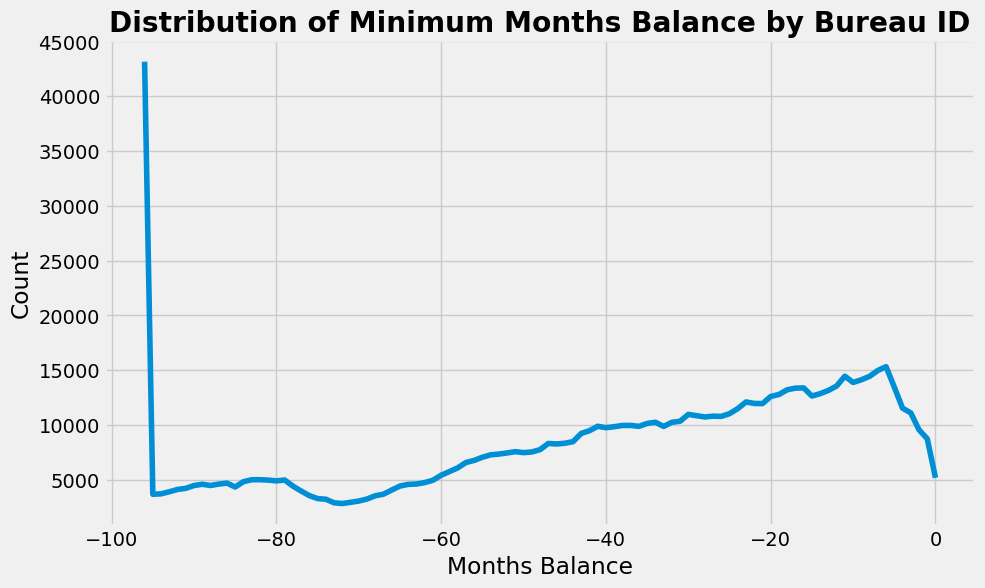

In [3]:
time_dist = balance.data.groupby('SK_ID_BUREAU')['MONTHS_BALANCE'].min().value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x=time_dist.index, y=time_dist.values)
plt.xlabel('Months Balance')
plt.ylabel('Count')
plt.title('Distribution of Minimum Months Balance by Bureau ID')
plt.show()


* Majority of applicant have history of spanning 100 months back.
    * Information older than 100 months (8.3 years) is not stored.
* Significant portion of individuals have less than 100 months of balance history, implying that the information was not collected about them.

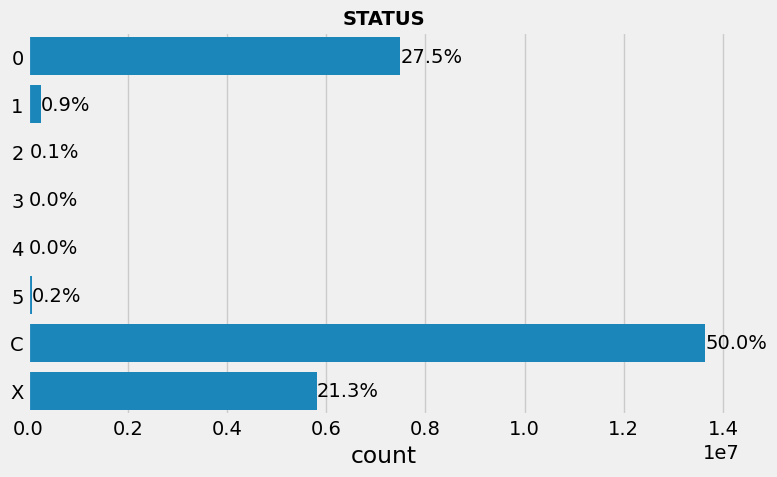

In [4]:
plot_categorical_dist(balance.data, 'STATUS');

* Majority of active loans were never past due.
* Half of data are closed loans.
* 21% of states are unknown and thus not informative.

# Transition of states
For a broad picture, we model the data as a **discrete-state discrete-time Markov process** with the following caveat:
* Individual application and time duration are ignored.
    - transition 1 and 99 months ago are considered equivalent.
    - Transitions that occurred in different individuals are identical to those that occurred within an individual.

Consequently, we consider all transitions of **X(id, t) -> X(id, t+1)**, where X is state (`STATUS`) id is `SK_ID_CURR` and t is `MONTHS_BALANCE`, as equivalent.

We thus construct a transition matrix from observed events, where: i (row) indicates the ingoing state and j (column) indicates the outgoing state.

We then count the observed transitions as:

In [5]:
transition_matrix = pd.DataFrame(0, index=sorted(balance.data['STATUS'].unique()), columns=sorted(balance.data['STATUS'].unique()))
df_sorted = balance.data.copy().sort_values(['SK_ID_BUREAU', 'MONTHS_BALANCE'])
df_sorted['next_status'] = df_sorted.groupby('SK_ID_BUREAU')['STATUS'].shift(-1)
transitions = df_sorted.dropna(subset=['next_status'])
df_sorted.head(100
               )

,SK_ID_BUREAU,MONTHS_BALANCE,STATUS,next_status
26079849,5001709,-96,X,X
26079848,5001709,-95,X,X
26079847,5001709,-94,X,X
26079846,5001709,-93,X,X
26079845,5001709,-92,X,X
...,...,...,...,...
26079754,5001709,-1,C,C
26079753,5001709,0,C,NaN
2846398,5001710,-82,X,X
2846397,5001710,-81,X,X


In [6]:
transition_counts = transitions.groupby(['STATUS', 'next_status'], observed=True).size()

for (current, next_state), count in transition_counts.items():
    transition_matrix.loc[next_state, current] += count

transition_matrix

,0,1,2,3,4,5,C,X
0,6299377,113244,5779,1090,402,1131,1,631094
1,145151,81874,3378,504,167,193,50,10182
2,3549,13845,4209,457,109,148,0,1001
3,225,229,6980,1019,138,71,0,224
4,38,2,147,4769,466,110,0,250
5,822,56,18,119,3821,55805,0,1609
C,356053,19273,1653,646,431,1880,13197338,51746
X,536964,8056,969,234,250,1810,1,4911373


Following observations can be made:
* Majority of closed accounts remain closed.
    * Ignoring a few outliers, closed account can be considered a transition state.
* Majority of active balances are paid on time.
* Majority of severe delinquencies (>120) remain in such state. 
* **Information is often lost. i.e. the state becomes unknown**

We then finish deriving the matrix:

In [7]:
transition_matrix = transition_matrix.div(transition_matrix.sum(axis=0), axis=1)
transition_matrix.round(2)

,0,1,2,3,4,5,C,X
0,0.86,0.48,0.25,0.12,0.07,0.02,0.0,0.11
1,0.02,0.35,0.15,0.06,0.03,0.00,0.0,0.00
2,0.00,0.06,0.18,0.05,0.02,0.00,0.0,0.00
3,0.00,0.00,0.30,0.12,0.02,0.00,0.0,0.00
4,0.00,0.00,0.01,0.54,0.08,0.00,0.0,0.00
5,0.00,0.00,0.00,0.01,0.66,0.91,0.0,0.00
C,0.05,0.08,0.07,0.07,0.07,0.03,1.0,0.01
X,0.07,0.03,0.04,0.03,0.04,0.03,0.0,0.88


We thus can derive such rules of thumb:
* Closed account is an absorbing state.
* Unknown balances remain unknown until an individual takes out a loan. i.e. the balance starts as paid.
* Delinquencies can only progress one at a time (effect of 30 days time scale).
* People tend to decrease delinquency severity
* Accounts at stage 5 (120+ / Sold / Written‑off) tend to stabilise.
    * The state is only realistic exited by paying off the debt or closing the account.
    * This is a huge oversight on status side, since it 3 states are agglomerated.

Consequently, if we treat prediction as a progression of probability distribution:
* All accounts will be eventually closed.
* Unknown accounts will progress into state 0.
* Balances of state 4,5 will tend to state 5 (before being closed).
* Balances of state 0, 1, 2, 3 will tend to lower states (before eventually being closed).

Thus **only individuals in states 4, 5 are in grounds for concerns**.



## Markov process predictive power.
We now evaluate the predictive power of the Markov process by predicting the t=0 state using t=1 state in our dataset. 

In [8]:
df = balance.data.copy()

states_df = df[df['MONTHS_BALANCE'].isin([-1, 0])].pivot_table(
    index='SK_ID_BUREAU', 
    columns='MONTHS_BALANCE', 
    values='STATUS', 
    aggfunc='first'
).rename(columns={-1: 'penul', 0: 'state'}).dropna()

states_df.head()

MONTHS_BALANCE,penul,state
SK_ID_BUREAU,,
5001709,C,C
5001710,C,C
5001711,0,X
5001712,C,C
5001713,X,X


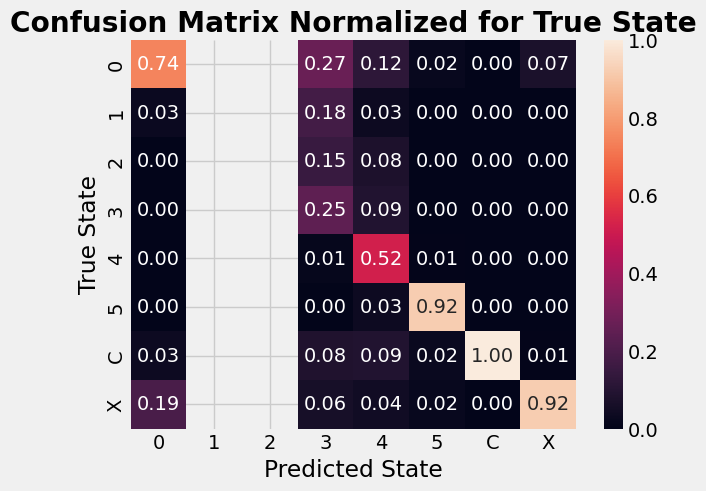

ROC AUC Score: 0.8900786636408607


In [ ]:
markov_predictor = MarkovPredictor(transition_matrix)

y_pred = markov_predictor.predict(states_df['penul'])
y_pred_proba = markov_predictor.predict_proba(states_df['penul'])


y_bin = markov_predictor.binarice_true_labels(states_df['state'])
cm = pd.DataFrame(confusion_matrix(y_bin, y_pred), index=markov_predictor.classes_, columns=markov_predictor.classes_)

sns.heatmap(cm/cm.sum(axis=0), annot=True, fmt='.2f')
plt.title('Confusion Matrix Normalized for True State')
plt.xlabel('Predicted State')
plt.ylabel('True State')
plt.show()

print("ROC AUC Score:", roc_auc_score(y_bin, y_pred_proba, multi_class='ovo'))

* States 1 and 2 were never predicted.
* State 0 was correctly assigned 75% of the time
* State 5 was often correctly assigned.
* State 3 was usually misaligned.
* ROC AUC 0.89 is affected by highly imbalanced data.

# 

## ML predictor:
Although such rules of thumb might be useful for individuals

```python
# Normalize the transition matrix to get transition probabilities

```

In [ ]:
transition_matrix

,C,0,X,1,2,3,5,4
C,4856,0,0,0,0,0,0,0
0,114,2054,233,44,0,0,0,0
X,24,268,2050,8,0,0,0,0
1,6,35,4,14,7,0,0,0
2,1,3,0,1,1,2,0,0
3,0,1,0,1,0,0,0,0
5,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0
